In [ ]:
!pip install compressai
!pip install pytorch-msssim
!pip install ipywidgets

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from torchvision import transforms
from PIL import Image
from compressai.zoo import cheng2020_anchor
import numpy as np
from pytorch_msssim import ms_ssim

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# DEFINICIÓN DE LA ARQUITECTURA
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class AdaptiveCheng2020Anchor(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_model = cheng2020_anchor(quality=3, pretrained=False)

    def forward(self, x, active_channels_ratio):
        y = self.base_model.g_a(x)
        N = y.size(1)
        c_keep = int(N * active_channels_ratio)
        mask = torch.zeros_like(y)
        mask[:, :c_keep, :, :] = 1.0
        y_masked = y * mask

        z = self.base_model.h_a(y_masked)
        z_hat, z_likelihoods = self.base_model.entropy_bottleneck(z)
        params = self.base_model.h_s(z_hat)

        y_hat = self.base_model.gaussian_conditional.quantize(y_masked, "dequantize")
        ctx_params = self.base_model.context_prediction(y_hat)
        gaussian_params = self.base_model.entropy_parameters(torch.cat((params, ctx_params), dim=1))
        scales_hat, means_hat = gaussian_params.chunk(2, 1)

        _, y_likelihoods = self.base_model.gaussian_conditional(y_masked, scales_hat, means_hat)
        x_hat = self.base_model.g_s(y_hat)

        return {'x_hat': x_hat, 'likelihoods': {'y': y_likelihoods, 'z': z_likelihoods}}

In [ ]:
# CARGA DEL MODELO Y LA IMAGEN

ruta_guardado = '/content/drive/MyDrive/Curso4/TFG/CHENG2020_Q3_MS-SSIM_2o4_12_H_01_S_005.pth'
ruta_imagen = '/content/drive/MyDrive/Curso4/TFG/DIV2K_HR_IMAGES/DIV2K_valid_HR/0801.png'

model = AdaptiveCheng2020Anchor().to(device)
model.load_state_dict(torch.load(ruta_guardado, map_location=device))
model.eval()

img_pil = Image.open(ruta_imagen).convert('RGB')
test_image_original = transforms.ToTensor()(img_pil).unsqueeze(0).to(device)

In [ ]:
def evaluar_codec_interactivo(ratio_canales):
    with torch.no_grad():
        _, _, h, w = test_image_original.size()
        pad_h = (64 - (h % 64)) % 64
        pad_w = (64 - (w % 64)) % 64
        img_padded = F.pad(test_image_original, (0, pad_w, 0, pad_h))

        # 1. Extraemos latentes puros
        y_puro = model.base_model.g_a(img_padded)
        N = y_puro.size(1)

        # 2. Ordenar los canales por energía (de mayor a menor)
        energia_canales = torch.mean(torch.abs(y_puro), dim=(0, 2, 3))
        ranking_energia = torch.argsort(energia_canales, descending=True)

        c_keep = int(N * ratio_canales)

        # 3. Crear la máscara apagando los canales con MENOS energía
        mask = torch.ones_like(y_puro)
        if c_keep < N:
            canales_inactivos = ranking_energia[c_keep:]
            mask[:, canales_inactivos, :, :] = 0.0

        y_masked = y_puro * mask

        # 4. Recreamos el paso manual para inyectar medias (bypass del modelo secuencial)
        z = model.base_model.h_a(y_masked)
        z_hat, z_likelihoods = model.base_model.entropy_bottleneck(z)
        params = model.base_model.h_s(z_hat)

        y_hat = model.base_model.gaussian_conditional.quantize(y_masked, "dequantize")
        ctx_params = model.base_model.context_prediction(y_hat)
        gaussian_params = model.base_model.entropy_parameters(torch.cat((params, ctx_params), dim=1))
        scales_hat, means_hat = gaussian_params.chunk(2, 1)

        y_for_likelihood = y_masked.clone()
        y_for_decoder = y_hat.clone()

        if c_keep < N:
            y_for_likelihood[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]
            y_for_decoder[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]

        _, y_likelihoods = model.base_model.gaussian_conditional(y_for_likelihood, scales_hat, means_hat)
        x_hat = model.base_model.g_s(y_for_decoder)

        # 5. Métricas de reconstrucción
        reconstruida_padded = x_hat.clamp(0, 1)
        reconstruida = reconstruida_padded[:, :, :h, :w]

        mse = torch.mean((test_image_original - reconstruida) ** 2)
        psnr = 10 * torch.log10(1.0 / mse)
        num_pixels = h * w

        # Usamos las probabilidades de nuestra pasada manual
        bpp = sum((torch.log(likelihoods).sum() / (-math.log(2) * num_pixels)) for likelihoods in [y_likelihoods, z_likelihoods])

        # ========================================================
        # 6. CONFIGURACIÓN DEL HEATMAP POR ENERGÍA
        # ========================================================
        energia_np = energia_canales.cpu().numpy()

        cols = 16
        rows = math.ceil(N / cols)

        # Matriz llena de NaN (saldrán en gris/apagados)
        matriz_energia = np.full(rows * cols, np.nan)

        if c_keep > 0:
            # Seleccionamos solo los índices de los mejores canales y asignamos su energía
            canales_activos = ranking_energia[:c_keep].cpu().numpy()
            for idx in canales_activos:
                matriz_energia[idx] = energia_np[idx]

        matriz_energia = matriz_energia.reshape((rows, cols))

        # ========================================================
        # 7. DIBUJO DE LAS GRÁFICAS
        # ========================================================
        img_orig_np = test_image_original[0].cpu().permute(1, 2, 0).numpy()
        img_recon_np = reconstruida[0].cpu().permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 1, 0.6]})

        ax[0].imshow(img_orig_np)
        ax[0].set_title(f"Original ({w}x{h})", fontsize=14)
        ax[0].axis('off')

        titulo_recon = f"Reconstruida | PSNR: {psnr:.2f} dB | Tasa: {bpp:.3f} bpp"
        ax[1].imshow(img_recon_np)
        ax[1].set_title(titulo_recon, fontsize=14, color='darkblue', fontweight='bold')
        ax[1].axis('off')

        cmap = plt.cm.magma.copy()
        cmap.set_bad(color='lightgray') # Color para los canales desactivados (NaN)

        # Fijamos el máximo al canal más fuerte de toda la imagen para no falsear los colores
        vmax_val = np.max(energia_np) + 0.1 if c_keep > 0 else 0.1

        im = ax[2].imshow(matriz_energia, cmap=cmap, aspect='equal', vmin=0, vmax=vmax_val)

        ax[2].set_xticks(np.arange(-.5, cols, 1), minor=True)
        ax[2].set_yticks(np.arange(-.5, rows, 1), minor=True)
        ax[2].grid(which='minor', color='w', linestyle='-', linewidth=1)
        ax[2].tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

        titulo_mapa = f"Energía de Canales Latentes\n(Matriz {rows}x{cols} = {N} Canales)"
        ax[2].set_title(titulo_mapa, fontsize=14, fontweight='bold')

        cbar = plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
        cbar.set_label('Nivel de Activación (Energía)', rotation=270, labelpad=15)

        plt.tight_layout()
        plt.show()

deslizador = widgets.FloatSlider(value=0.5, min=0.01, max=1.0, step=0.01, description='Calidad:', continuous_update=False)
print("Mueve el deslizador para ver el descarte inteligente por energía y la inyección de medias:")
widgets.interact(evaluar_codec_interactivo, ratio_canales=deslizador);

Mueve el deslizador para ver el descarte inteligente por energía y la inyección de medias:


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='Calidad:', max=1.0, min=0.0…

Evaluando los 128 puntos de la curva RD ordenados por energía...


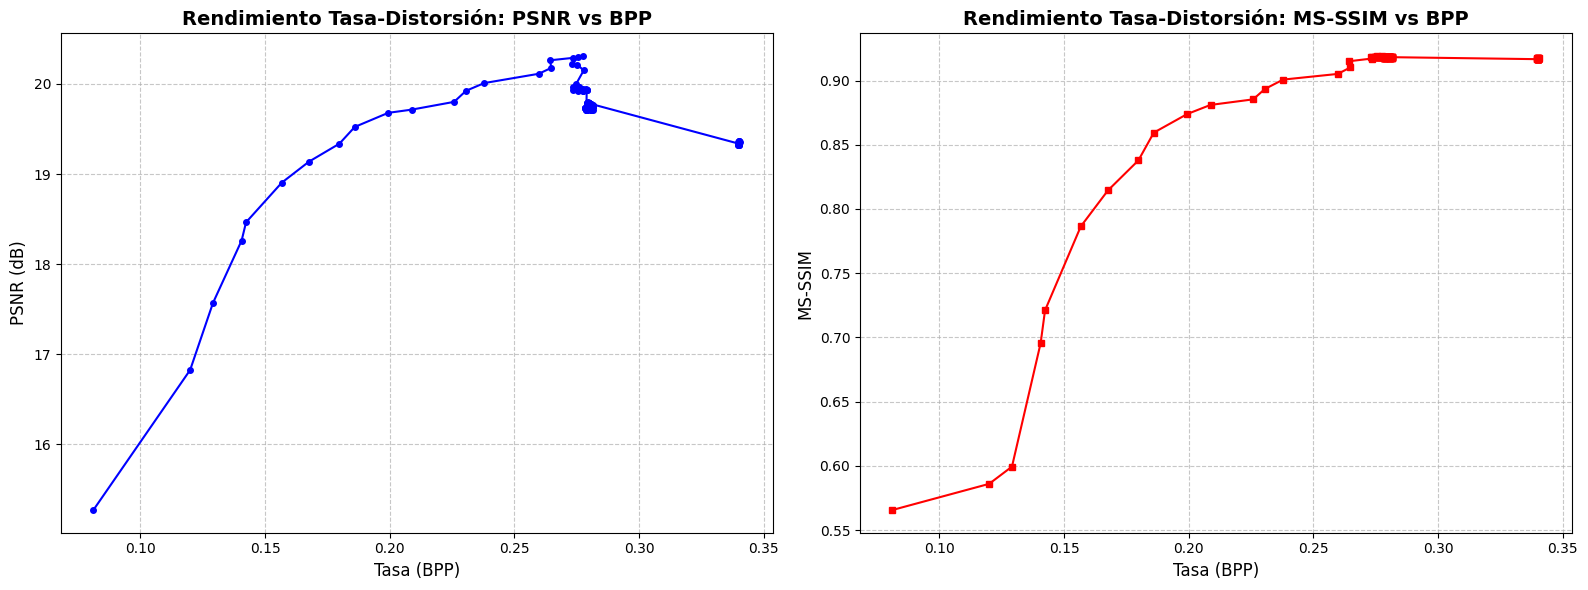

In [ ]:
bpp_list = []
psnr_list = []
msssim_list = []

model.eval()

with torch.no_grad():
    _, _, h, w = test_image_original.size()
    pad_h = (64 - (h % 64)) % 64
    pad_w = (64 - (w % 64)) % 64
    img_padded = F.pad(test_image_original, (0, pad_w, 0, pad_h))

    y_puro = model.base_model.g_a(img_padded)
    N = y_puro.size(1)

    # Ordenar los canales por energía (de mayor a menor)
    energia_canales = torch.mean(torch.abs(y_puro), dim=(0, 2, 3))
    ranking_energia = torch.argsort(energia_canales, descending=True)

    print(f"Evaluando los {N} puntos de la curva RD ordenados por energía...")

    for c_keep in range(1, N + 1):

        # 1. Crear la máscara: Desactivamos (ponemos a 0) los canales con MENOS energía
        mask = torch.ones_like(y_puro)
        if c_keep < N:
            # Seleccionamos todos los canales desde el índice c_keep hasta el final (los de menor energía)
            canales_inactivos = ranking_energia[c_keep:]
            mask[:, canales_inactivos, :, :] = 0.0

        y_masked = y_puro * mask

        # 2. Recreamos el paso por la red manualmente SIN alterar las propiedades del modelo original
        z = model.base_model.h_a(y_masked)
        z_hat, z_likelihoods = model.base_model.entropy_bottleneck(z)
        params = model.base_model.h_s(z_hat)

        y_hat = model.base_model.gaussian_conditional.quantize(y_masked, "dequantize")
        ctx_params = model.base_model.context_prediction(y_hat)
        gaussian_params = model.base_model.entropy_parameters(torch.cat((params, ctx_params), dim=1))
        scales_hat, means_hat = gaussian_params.chunk(2, 1)

        # 3. Inyectamos las medias en los canales desactivados (para no penalizar el BPP)
        y_for_likelihood = y_masked.clone()
        y_for_decoder = y_hat.clone()

        if c_keep < N:
            y_for_likelihood[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]
            y_for_decoder[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]

        _, y_likelihoods = model.base_model.gaussian_conditional(y_for_likelihood, scales_hat, means_hat)
        x_hat = model.base_model.g_s(y_for_decoder)

        # 4. Cálculo de métricas
        reconstruida_padded = x_hat.clamp(0, 1)
        reconstruida = reconstruida_padded[:, :, :h, :w]

        mse = torch.mean((test_image_original - reconstruida) ** 2)
        psnr = 10 * torch.log10(1.0 / mse)

        msssim_val = ms_ssim(reconstruida, test_image_original, data_range=1.0, size_average=True)

        num_pixels = h * w
        # Al pasarlo manual, recolectamos las probabilidades de y_likelihoods y z_likelihoods
        bpp = sum((torch.log(likelihoods).sum() / (-math.log(2) * num_pixels)) for likelihoods in [y_likelihoods, z_likelihoods])

        bpp_list.append(bpp.item())
        psnr_list.append(psnr.item())
        msssim_list.append(msssim_val.item())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(bpp_list, psnr_list, marker='o', linestyle='-', color='b', markersize=4)
ax1.set_title('Rendimiento Tasa-Distorsión: PSNR vs BPP', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tasa (BPP)', fontsize=12)
ax1.set_ylabel('PSNR (dB)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(bpp_list, msssim_list, marker='s', linestyle='-', color='r', markersize=4)
ax2.set_title('Rendimiento Tasa-Distorsión: MS-SSIM vs BPP', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tasa (BPP)', fontsize=12)
ax2.set_ylabel('MS-SSIM', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()